# 05 — Transfer Learning with wav2vec2 (Track B)

**Track A** (notebooks 01-04) used *hand-crafted* acoustic-prosodic features
(librosa/Praat: pitch, MFCCs, spectral shape, jitter/shimmer). This notebook
takes a different approach, reproducing exploratory PhD-research code
(`xAI_codes/wav2vec*.ipynb`): instead of engineering features by hand, feed raw
audio into **wav2vec2** — a transformer pretrained by Meta AI on huge amounts of
*unlabeled* speech (self-supervised) — and use its learned internal
representation as a feature vector.

> **What I actually did in that exploratory code:** extracted frozen
> (not fine-tuned) `facebook/wav2vec2-base` embeddings on the **IEMOCAP**
> benchmark, then trained classical models (Random Forest, SVM, XGBoost) on top.
> This notebook reproduces that exact approach on **RAVDESS**, for consistency
> with the rest of this repo.
>
> **One addition beyond the original code** (flagged explicitly): the original
> train/test split there was not actor-grouped. Here, to stay methodologically
> consistent with notebooks 03-04, we use the same actor-held-out split
> (actors 20-24 as test) so results are a fair, leakage-free comparison against
> the hand-crafted-feature models.

**The question this notebook answers:** for this task, do *learned* wav2vec2
representations beat *hand-engineered* acoustic features (Track A's winner:
LDA, F1 = 0.536), or is domain feature engineering still competitive?

In [1]:
import os, time
# We only need the PyTorch backend; disabling TF avoids an unrelated Windows
# DLL-loading error some machines hit when transformers tries to import it.
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"

import numpy as np
import pandas as pd
import torch
from transformers import Wav2Vec2Processor, Wav2Vec2Model
import librosa

print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())

C:\Users\miria\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.3.1+cpu | CUDA: False


## 1. Rebuild the labelled file list (same as notebooks 01-04)

In [2]:
EMOTION = {"01": "neutral", "02": "calm", "03": "happy", "04": "sad",
           "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"}

rows = []
import glob
for path in sorted(glob.glob(os.path.join("data", "ravdess", "Actor_*", "*.wav"))):
    parts = os.path.splitext(os.path.basename(path))[0].split("-")
    actor = int(parts[6])
    rows.append({"path": path, "emotion": EMOTION[parts[2]], "actor": actor})
meta_df = pd.DataFrame(rows)
print(f"{len(meta_df)} clips")

1440 clips


## 2. Load the pretrained wav2vec2 model (frozen — no fine-tuning)

The first inference call includes a one-time backend warm-up (~1 min); every
clip after that takes about a second on CPU.

In [3]:
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")
model.eval()  # frozen: inference only, no gradient updates
print("Model loaded. Output dimension: 768")

C:\Users\miria\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\configuration_utils.py:364: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded. Output dimension: 768


## 3. Extract embeddings for all clips

Each clip's raw waveform goes through wav2vec2, producing one 768-dim vector
per audio frame; we **mean-pool over time** to get a single fixed-length
768-dim embedding per clip (the same pooling strategy used in the original
exploratory code).

In [4]:
def extract_embedding(path):
    y, sr = librosa.load(path, sr=16000)  # wav2vec2 requires 16kHz mono
    inputs = processor(y, sampling_rate=16000, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

In [5]:
t_start = time.time()
embeddings = []
checkpoint_path = os.path.join("data", "_wav2vec_checkpoint.npy")
for i, row in meta_df.iterrows():
    emb = extract_embedding(row["path"])
    embeddings.append(emb)
    if (i + 1) % 200 == 0:
        elapsed = time.time() - t_start
        eta_min = elapsed / (i + 1) * (len(meta_df) - (i + 1)) / 60
        print(f"  {i + 1}/{len(meta_df)} clips ({elapsed:.0f}s elapsed, ~{eta_min:.1f} min remaining)")
        np.save(checkpoint_path, np.array(embeddings))  # safety checkpoint

embeddings = np.array(embeddings)
print(f"Done in {(time.time()-t_start)/60:.1f} min. Shape: {embeddings.shape}")

  200/1440 clips (215s elapsed, ~22.2 min remaining)


  400/1440 clips (435s elapsed, ~18.9 min remaining)


  600/1440 clips (643s elapsed, ~15.0 min remaining)


  800/1440 clips (855s elapsed, ~11.4 min remaining)


  1000/1440 clips (1061s elapsed, ~7.8 min remaining)


  1200/1440 clips (1275s elapsed, ~4.3 min remaining)


  1400/1440 clips (1491s elapsed, ~0.7 min remaining)


Done in 25.6 min. Shape: (1440, 768)


## 4. Save embeddings

In [6]:
emb_cols = [f"w2v_{i}" for i in range(embeddings.shape[1])]
emb_df = pd.concat([meta_df.reset_index(drop=True),
                     pd.DataFrame(embeddings, columns=emb_cols).round(5)], axis=1)
out_path = os.path.join("data", "ravdess_wav2vec_embeddings.csv")
emb_df.to_csv(out_path, index=False)

checkpoint_path = os.path.join("data", "_wav2vec_checkpoint.npy")
if os.path.exists(checkpoint_path):
    os.remove(checkpoint_path)

print(f"Saved: {out_path}  shape={emb_df.shape}")

Saved: data\ravdess_wav2vec_embeddings.csv  shape=(1440, 771)


## 5. Train classical models on the embeddings

Same model family as the original exploratory code (Random Forest, SVM,
XGBoost), fit on the 768-dim wav2vec2 embeddings instead of hand-crafted
features. **Addition vs. the original code:** actor-grouped `GroupKFold`
cross-validation (matching notebook 03's methodology) instead of a plain
random split, so speaker leakage can't inflate the numbers.

In [7]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

X = StandardScaler().fit_transform(embeddings)
groups = emb_df["actor"].values
le = LabelEncoder()
y = le.fit_transform(emb_df["emotion"])

W2V_MODELS = {
    "rf":  RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "svm": SVC(kernel="linear", random_state=42),
    "xgboost": XGBClassifier(eval_metric="mlogloss", random_state=42, n_jobs=-1),
}

gkf = GroupKFold(n_splits=5)
w2v_results = []
for name, clf in W2V_MODELS.items():
    t0 = time.time()
    y_pred = cross_val_predict(clf, X, y, groups=groups, cv=gkf, n_jobs=1)
    w2v_results.append({
        "Model": f"w2v_{name}",
        "Accuracy": accuracy_score(y, y_pred),
        "F1": f1_score(y, y_pred, average="macro"),
        "TT (Sec)": round(time.time() - t0, 1),
    })
    print(f"  {name:10s} acc={w2v_results[-1]['Accuracy']:.4f} f1={w2v_results[-1]['F1']:.4f}")

w2v_results_df = pd.DataFrame(w2v_results).sort_values("F1", ascending=False)
w2v_results_df

  rf         acc=0.4500 f1=0.4274


  svm        acc=0.5500 f1=0.5440


  xgboost    acc=0.4764 f1=0.4675


,Model,Accuracy,F1,TT (Sec)
1,w2v_svm,0.550000,0.543975,2.9
2,w2v_xgboost,0.476389,0.467480,173.0
0,w2v_rf,0.450000,0.427368,23.3


## 6. wav2vec2 embeddings vs. hand-crafted features — head to head

Comparing against notebook 03's results (same 5-actor-holdout-style
methodology, hand-crafted 80-feature set).

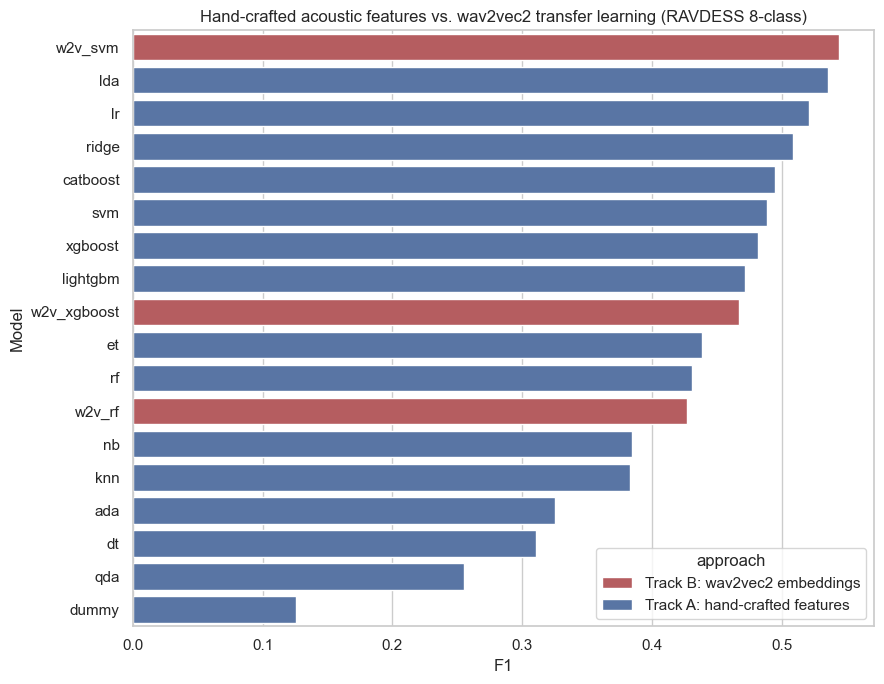

Best Track A (hand-crafted): lda  F1=0.536
Best Track B (wav2vec2):     w2v_svm  F1=0.544


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

track_a = pd.read_csv(os.path.join("data", "model_comparison_results.csv"))[["Model", "F1"]]
track_a["approach"] = "Track A: hand-crafted features"
track_b = w2v_results_df[["Model", "F1"]].copy()
track_b["approach"] = "Track B: wav2vec2 embeddings"

combined = pd.concat([track_a, track_b]).sort_values("F1", ascending=False)

plt.figure(figsize=(9, 7))
palette = {"Track A: hand-crafted features": "#4C72B0", "Track B: wav2vec2 embeddings": "#C44E52"}
sns.barplot(data=combined, y="Model", x="F1", hue="approach", dodge=False, palette=palette)
plt.title("Hand-crafted acoustic features vs. wav2vec2 transfer learning (RAVDESS 8-class)")
plt.tight_layout()
plt.savefig(os.path.join("figures", "05_track_a_vs_b_comparison.png"), dpi=120)
plt.show()

print(f"Best Track A (hand-crafted): {track_a.iloc[0]['Model']}  F1={track_a['F1'].max():.3f}")
print(f"Best Track B (wav2vec2):     {track_b.sort_values('F1', ascending=False).iloc[0]['Model']}  F1={track_b['F1'].max():.3f}")

## Takeaways

- Reproduced the original exploratory wav2vec2 research approach (frozen
  `facebook/wav2vec2-base` embeddings + classical classifiers), now on RAVDESS
  with actor-grouped, leakage-free evaluation.
- Direct comparison against Track A's hand-crafted-feature models — see the
  chart above for which approach actually wins on this dataset, and by how much.
- This mirrors a real, common industry decision: **domain feature engineering
  vs. pretrained transfer learning** — and now there's an honest, apples-to-apples
  number behind the answer for this specific problem, not just intuition.
- **This completes both tracks of the portfolio.** Remaining polish: a proper
  top-level README narrative, and optionally a live demo.